# Data exploration

Objectif de ce notebook :

- charger le dataset d'électricité et météo ;
- comprendre la structure des données ;
- vérifier les types de colonnes ;
- identifier les valeurs manquantes ;
- produire les premières statistiques descriptives ;
- préparer les prochaines étapes de nettoyage et de modélisation.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
data_path = "../data/electricity_consumption_based_weather_dataset.csv"
df = pd.read_csv(data_path)
df.head(5)

,date,AWND,PRCP,TMAX,TMIN,daily_consumption
0,2006-12-16,2.5,0.0,10.6,5.0,1209.176
1,2006-12-17,2.6,0.0,13.3,5.6,3390.460
2,2006-12-18,2.4,0.0,15.0,6.7,2203.826
3,2006-12-19,2.4,0.0,7.2,2.2,1666.194
4,2006-12-20,2.4,0.0,7.2,1.1,2225.748


In [44]:
df.shape

(1433, 6)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               1433 non-null   object 
 1   AWND               1418 non-null   float64
 2   PRCP               1433 non-null   float64
 3   TMAX               1433 non-null   float64
 4   TMIN               1433 non-null   float64
 5   daily_consumption  1433 non-null   float64
dtypes: float64(5), object(1)
memory usage: 67.3+ KB


In [46]:
df.isna().sum()

date                  0
AWND                 15
PRCP                  0
TMAX                  0
TMIN                  0
daily_consumption     0
dtype: int64

In [47]:
df.describe()

,AWND,PRCP,TMAX,TMIN,daily_consumption
count,1418.000000,1433.000000,1433.000000,1433.000000,1433.000000
mean,2.642313,3.800488,17.187509,9.141242,1561.078061
std,1.140021,10.973436,10.136415,9.028417,606.819667
min,0.000000,0.000000,-8.900000,-14.400000,14.218000
25%,1.800000,0.000000,8.900000,2.200000,1165.700000
50%,2.400000,0.000000,17.800000,9.400000,1542.650000
75%,3.300000,1.300000,26.100000,17.200000,1893.608000
max,10.200000,192.300000,39.400000,27.200000,4773.386000


In [48]:
df["date"] = pd.to_datetime(df["date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               1433 non-null   datetime64[ns]
 1   AWND               1418 non-null   float64       
 2   PRCP               1433 non-null   float64       
 3   TMAX               1433 non-null   float64       
 4   TMIN               1433 non-null   float64       
 5   daily_consumption  1433 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 67.3 KB


In [49]:
df["date"].min(), df["date"].max()

(Timestamp('2006-12-16 00:00:00'), Timestamp('2010-11-26 00:00:00'))

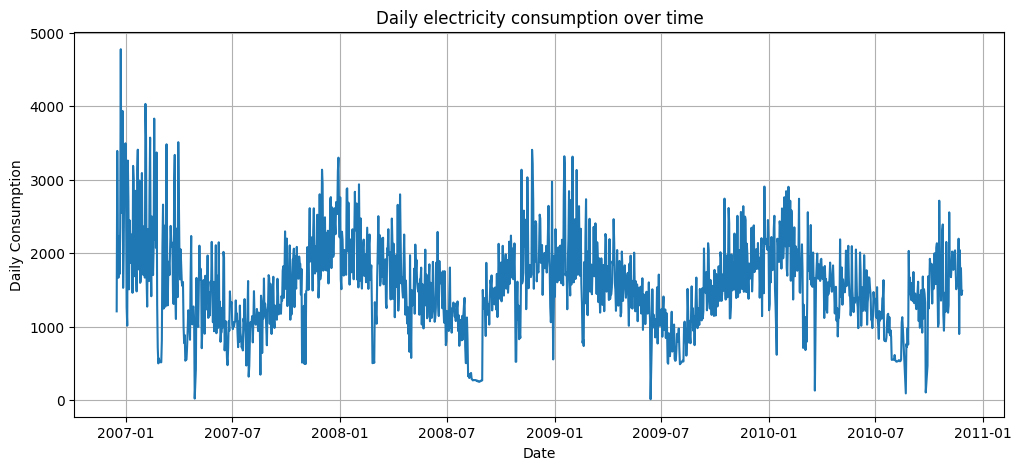

In [50]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["daily_consumption"])

plt.title("Daily electricity consumption over time")
plt.xlabel("Date")
plt.ylabel("Daily Consumption")
plt.grid(True)

plt.show()

In [51]:
df.sort_values("daily_consumption", ascending=False).head(10)

,date,AWND,PRCP,TMAX,TMIN,daily_consumption
7,2006-12-23,3.0,19.8,15.0,8.9,4773.386
49,2007-02-03,3.9,0.0,1.7,-5.0,4029.722
10,2006-12-26,3.3,2.0,11.7,6.1,3934.110
64,2007-02-18,3.4,0.0,1.1,-7.8,3829.762
50,2007-02-04,4.5,0.0,-2.2,-8.3,3595.940
57,2007-02-11,2.6,0.0,0.6,-7.2,3571.228
105,2007-03-31,2.2,0.0,15.6,6.1,3509.510
15,2006-12-31,2.1,0.0,7.2,0.6,3494.196
85,2007-03-11,3.0,4.1,10.0,3.3,3480.636
36,2007-01-21,1.6,0.0,-1.7,-7.2,3407.262


In [52]:
df.sort_values("daily_consumption", ascending=True).head(10)

,date,AWND,PRCP,TMAX,TMIN,daily_consumption
909,2009-06-13,1.9,3.3,22.8,16.1,14.218
133,2007-04-28,1.8,0.0,21.7,12.2,22.738
1338,2010-08-22,2.9,42.9,26.7,20.6,93.338
1372,2010-09-25,3.2,0.0,31.7,19.4,106.006
1187,2010-03-20,2.2,0.0,23.3,12.2,131.732
617,2008-08-25,2.6,0.0,29.4,19.4,250.298
615,2008-08-23,1.7,0.0,27.2,18.9,254.642
616,2008-08-24,2.2,0.0,27.8,20.0,254.716
618,2008-08-26,2.7,0.0,26.7,16.1,257.564
619,2008-08-27,2.3,0.0,26.1,16.1,258.114


## Weather variables and consumption

We now explore how weather variables relate to daily electricity consumption.

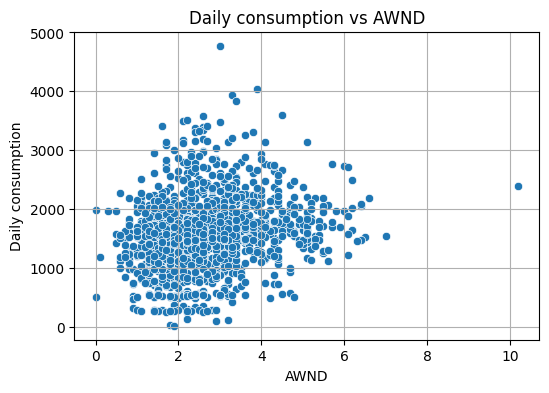

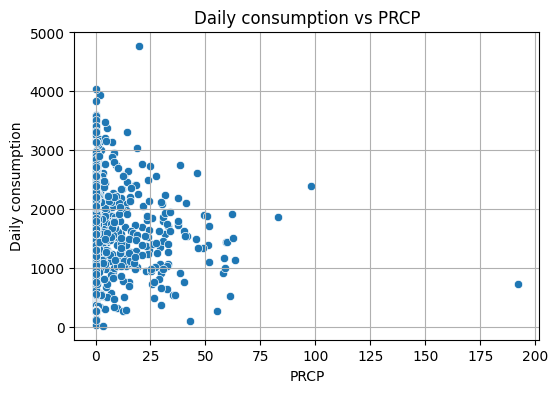

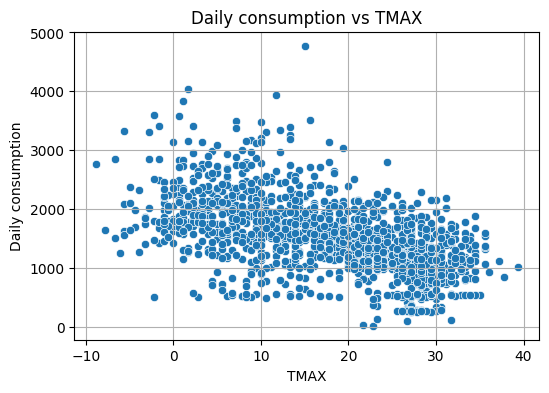

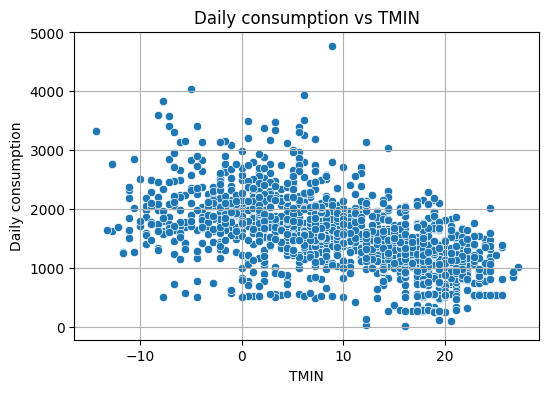

In [53]:
weather_columns = ["AWND", "PRCP", "TMAX", "TMIN"]

for column in weather_columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=column, y="daily_consumption")
    plt.title(f"Daily consumption vs {column}")
    plt.xlabel(column)
    plt.ylabel("Daily consumption")
    plt.grid(True)
    plt.show()



## Correlation analysis

We compute correlations between weather variables and daily electricity consumption.

In [54]:
numeric_columns = ["AWND", "PRCP", "TMAX", "TMIN", "daily_consumption"]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,AWND,PRCP,TMAX,TMIN,daily_consumption
AWND,1.000000,0.135441,-0.480673,-0.463924,0.236185
PRCP,0.135441,1.000000,-0.019111,0.027696,-0.036427
TMAX,-0.480673,-0.019111,1.000000,0.956701,-0.525494
TMIN,-0.463924,0.027696,0.956701,1.000000,-0.526822
daily_consumption,0.236185,-0.036427,-0.525494,-0.526822,1.000000


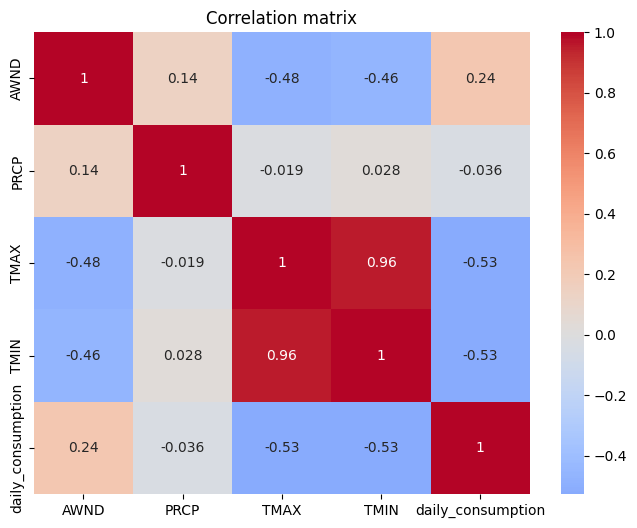

In [55]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
)

plt.title("Correlation matrix")
plt.show()

## Correlation takeaways

The correlation matrix suggests that temperature is the strongest weather-related signal in this dataset. Both `TMAX` and `TMIN` have a moderate negative linear correlation with `daily_consumption`, meaning that electricity consumption tends to be higher when temperatures are lower.

`TMAX` and `TMIN` are also highly correlated with each other, which is expected because daily minimum and maximum temperatures usually move together. This may matter later for linear models, since strongly correlated input variables can make coefficient interpretation harder.

Precipitation appears to have almost no linear relationship with daily consumption in this dataset. Wind speed has a weaker positive relationship, but this may partly reflect colder and windier winter days rather than a direct causal effect.

## Monthly consumption patterns

The time-series plot suggests a seasonal pattern, with higher consumption during colder months. We now compare average daily consumption by month.

In [56]:
df["month"] = df["date"].dt.month

monthly_consumption = df.groupby("month")["daily_consumption"].mean()

monthly_consumption 

month
1     2085.454553
2     1871.803133
3     1752.965081
4     1487.774000
5     1482.523887
6     1294.573143
7     1007.737452
8      813.484317
9     1385.410051
10    1637.052452
11    1857.702017
12    2129.874954
Name: daily_consumption, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

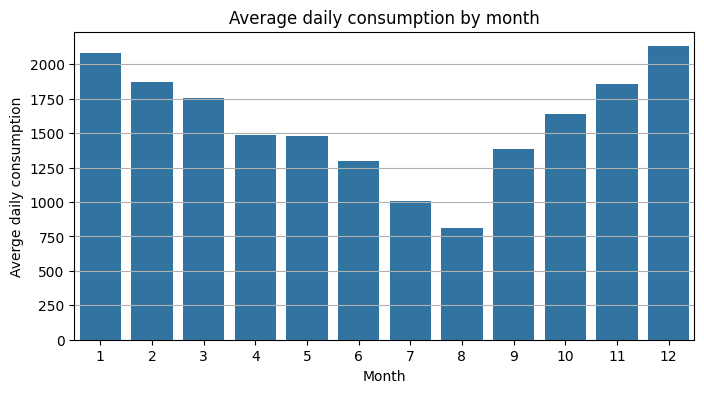

In [57]:
plt.figure(figsize=(8,4))

sns.barplot(
    x=monthly_consumption.index,
    y=monthly_consumption.values
)

plt.title("Average daily consumption by month")
plt.xlabel("Month")
plt.ylabel("Averge daily consumption")
plt.grid(axis="y")

plt.show

The monthly average confirms a clear seasonal pattern. Daily electricity consumption is highest in winter, especially in December and January, and lowest during summer months such as July and August.

This supports the hypothesis that temperature and seasonality are key drivers of electricity demand in this dataset.

## Weekday consumption patterns

After observing monthly seasonality, we check whether electricity consumption also changes depending on the day of the week.

In [58]:
df["day_of_week"] = df["date"].dt.day_name()

df["day_of_week"]

weekday_consumption = df.groupby("day_of_week")["daily_consumption"].mean()

weekday_consumption

day_of_week
Friday       1501.535551
Monday       1432.851746
Saturday     1758.770244
Sunday       1743.299823
Thursday     1404.025561
Tuesday      1530.586563
Wednesday    1558.390343
Name: daily_consumption, dtype: float64

In [59]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_consumption = weekday_consumption.reindex(weekday_order)

weekday_consumption 

day_of_week
Monday       1432.851746
Tuesday      1530.586563
Wednesday    1558.390343
Thursday     1404.025561
Friday       1501.535551
Saturday     1758.770244
Sunday       1743.299823
Name: daily_consumption, dtype: float64

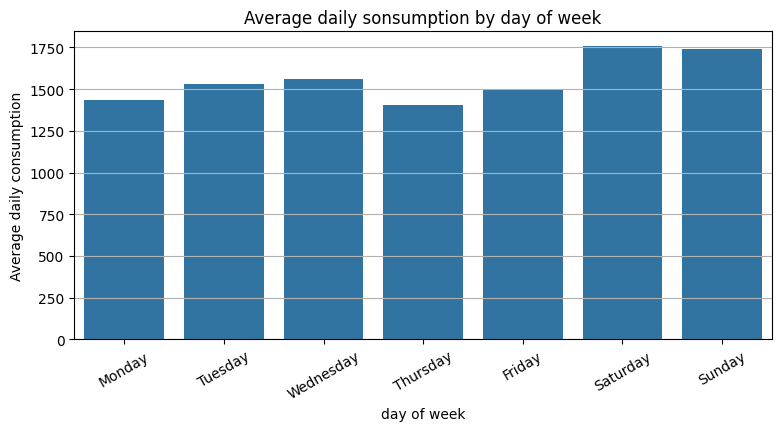

In [61]:
plt.figure(figsize=(9,4))

sns.barplot(
    x = weekday_consumption.index,
    y= weekday_consumption
)

plt.title("Average daily sonsumption by day of week")
plt.xlabel("day of week")
plt.ylabel("Average daily consumption")
plt.xticks(rotation=30)
plt.grid(axis="y")

plt.show()

The weekday analysis suggests that average daily electricity consumption is higher during the weekend, especially on Saturday and Sunday.

This pattern may reflect different household or activity routines compared with weekdays. Since the dataset is daily, we cannot directly explain the cause, but the result suggests that calendar-based features may be useful for prediction.

## Exploration summary

This first exploration shows several important patterns:

- the dataset contains 1,433 daily observations from December 2006 to November 2010;
- `AWND` has a small number of missing values;
- electricity consumption shows a clear seasonal pattern, with higher values during winter months;
- temperature variables are moderately negatively correlated with daily consumption;
- weekend days appear to have higher average consumption than weekdays;
- some extremely low consumption values may need further investigation during the data cleaning step.

The next step will be to clean the data and decide how to handle missing values and potential outliers before building predictive models.